<a href="https://colab.research.google.com/github/shikha-naveenkumar/CITS2402---Introduction-to-Data-Science---Project./blob/main/CITS2402_Project_25555469_24275153_25543365.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CITS2402 - Introduction to Data Science - Project.

### How Do Educational Qualifications Differ Across Australia and New Zealand at Multiple Levels, and What Do These Differences Suggest About the Educational Composition of Their Populations?

**Date:** October 2026.

## Declaration


*I/we am/are aware of the University’s [policy on academic conduct](https://www.uwa.edu.au/policy/-/media/project/uwa/uwa/policy-library/policy/student-administration/academic-integrity/academic-integrity-policy.doc) and I declare that this assignment is entirely the work of the author(s) listed below and that suitable acknowledgement has been made for any sources of information used in preparing it. I have retained a copy for my own records.*

- Name 1: Shikha Naveenkumar
- Student ID 1: 25555469
- Name 2: Brinya Wakefield
- Student ID 2: 24275153
- Name 3: Laura Ribeiro
- Student ID 3: 25543365
- Date: 2 October 2026


# 1. Introduction

## 1.1 Background

Educational qualifications provide an indication of the formal educational attainment of a population. Australia and New Zealand both conduct national censuses that collect information about educational qualifications, but the information is organised using different classification systems and census years.

This project compares educational qualification data from the 2021 Australian Census and the 2023 New Zealand Census. The analysis focuses on broad qualification categories to examine how the formal educational composition of the populations differs between the two countries.

The comparison is based on publicly available census data from the Australian Bureau of Statistics (ABS) and Stats NZ. Because the two countries use different qualification categories and have different census years, the data must first be cleaned and mapped into broader categories that allow a meaningful comparison.

The analysis describes differences in the distribution of formal educational qualifications and considers what these differences suggest about the educational composition of the two populations. The results should not be interpreted as a direct measure of the skills possessed by individuals, since formal qualifications do not capture all skills, knowledge, or experience.

## 1.2 Research Question

**How Do Educational Qualifications Differ Across Australia and New Zealand at Multiple Levels, and What Do These Differences Suggest About the Educational Composition of Their Populations?**

### 1.3 Sub-questions

The analysis will address the following questions:

1. How does the distribution of the four comparable qualification categories differ between Australia and New Zealand?

2. How does the distribution of vocational and higher education qualifications differ between the two countries?

3. Within the higher education qualifications represented in the comparable data, how does the distribution of Bachelor and Postgraduate qualifications differ between Australia and New Zealand?

4. What limitations and assumptions arise when comparing qualification data from the 2021 Australian Census and the 2023 New Zealand Census?

## 2. Data Sources

### 2.1 Australia — 2021 Census

The Australian data were obtained from the Australian Bureau of Statistics (ABS) 2021 Census General Community Profile DataPack. The relevant table used in this project is **G49A — Highest non-school qualification: level of education by age by sex**.

G49A provides counts for people aged 15 years and over according to their highest completed non-school qualification, with the data further classified by age and sex. The analysis uses the Australia-level records and retains the male and female count variables required for the data preparation and analysis.

The qualification categories used from G49A include Postgraduate Degree, Graduate Diploma/Graduate Certificate, Bachelor Degree, Advanced Diploma/Diploma, Certificate III/IV, Certificate I/II, and Certificate level not further defined.

The G49A CSV file was extracted from the Australian Census General Community Profile DataPack and is included alongside the submitted notebook so that the analysis can be reproduced.

### 2.2 New Zealand — 2023 Census

The New Zealand data were obtained from **Stats NZ Aotearoa Data Explorer**, using the 2023 Census table **“Highest qualification, ethnicity (detailed total responses level 3), and age (life cycle groups) for the census usually resident population count aged 15 years and over”**.

For this project, the data were selected for the 2023 Census, “Total - New Zealand by regional council”, Total ethnicity, and Total age. The resulting data provide counts for the different highest qualification categories for the New Zealand population aged 15 years and over.

The selected table was downloaded as a CSV file and is included alongside the submitted notebook so that the analysis can be reproduced.

### 2.3 Differences Between the Data Sources

The Australian and New Zealand data are not identical in structure. The Australian data are from the 2021 Census, while the New Zealand data are from the 2023 Census. In addition, the two statistical agencies use different qualification classification systems.

Therefore, the qualification categories cannot be compared directly in their original form. For the analysis, the categories are cleaned and mapped into broader qualification groups that are sufficiently comparable across the two countries.

The differences in census year, qualification classifications, and available demographic dimensions are treated as limitations of the comparison and are considered when interpreting the results.

### 2.4 Data Selection and Reproducibility

The project uses only the individual CSV tables required for the analysis rather than the complete Australian Census DataPack. The raw CSV files are kept unchanged and are supplied alongside the notebook.

All filtering, cleaning, transformation, aggregation, and analysis are performed programmatically in Python. This allows the results to be reproduced from the original data files without manually modifying the source data.

# 3. Data Preparation

The raw Australian and New Zealand Census datasets were processed using Python. The source CSV files were not manually modified. Data preparation consisted of loading the raw files, selecting the relevant observations and variables, converting count values to numeric form, and grouping the original qualification categories into broader categories that can be compared across the two countries.

The processing steps are performed programmatically so that the analysis can be reproduced from the submitted raw data files.

### 3.1 Loading the Raw Data

The raw Australian and New Zealand Census data are loaded directly from the submitted CSV files using Python. The source files are not manually modified. Keeping the raw data unchanged allows the subsequent extraction and cleaning steps to be reproduced from the original files.

In [ ]:
import pandas as pd
import numpy as np

# Load the raw Australian and New Zealand Census datasets
aus_raw = pd.read_csv("2021Census_G49A_AUS_AUS.csv")

nz_raw = pd.read_csv(
    "STATSNZ,CEN23_ECI_010,1.0+2023.9999..9999.99.csv"
)

print("Australian dataset shape:", aus_raw.shape)
print("New Zealand dataset shape:", nz_raw.shape)

Australian dataset shape: (1, 201)
New Zealand dataset shape: (15, 18)


In [ ]:
# Inspect the structure of the raw datasets

print("Australian columns:")
print(aus_raw.columns.tolist())

print("\nNew Zealand columns:")
print(nz_raw.columns.tolist())

Australian columns:
['AUS_CODE_2021', 'M_PGrad_Deg_15_24', 'M_PGrad_Deg_25_34', 'M_PGrad_Deg_35_44', 'M_PGrad_Deg_45_54', 'M_PGrad_Deg_55_64', 'M_PGrad_Deg_65_74', 'M_PGrad_Deg_75_84', 'M_PGrad_Deg_85ov', 'M_PGrad_Deg_Total', 'M_GradDip_and_GradCert_15_24', 'M_GradDip_and_GradCert_25_34', 'M_GradDip_and_GradCert_35_44', 'M_GradDip_and_GradCert_45_54', 'M_GradDip_and_GradCert_55_64', 'M_GradDip_and_GradCert_65_74', 'M_GradDip_and_GradCert_75_84', 'M_GradDip_and_GradCert_85ov', 'M_GradDip_and_GradCert_Total', 'M_BachDeg_15_24', 'M_BachDeg_25_34', 'M_BachDeg_35_44', 'M_BachDeg_45_54', 'M_BachDeg_55_64', 'M_BachDeg_65_74', 'M_BachDeg_75_84', 'M_BachDeg_85ov', 'M_BachDeg_Total', 'M_AdvDip_and_Dip_15_24', 'M_AdvDip_and_Dip_25_34', 'M_AdvDip_and_Dip_35_44', 'M_AdvDip_and_Dip_45_54', 'M_AdvDip_and_Dip_55_64', 'M_AdvDip_and_Dip_65_74', 'M_AdvDip_and_Dip_75_84', 'M_AdvDip_and_Dip_85ov', 'M_AdvDip_and_Dip_Total', 'M_Cert_III_IV_15_24', 'M_Cert_III_IV_25_34', 'M_Cert_III_IV_35_44', 'M_Cert_III_IV_

### 3.2 Australia — Extracting and Cleaning Relevant Variables

The Australian G49A dataset contains one Australia-level record with qualification, age, sex, and total-count variables stored across its columns. For this analysis, only the age-specific male and female counts for the selected qualification categories are required.

The total and subtotal columns are excluded to avoid double-counting. The remaining columns are reshaped from wide format into a long format, and the qualification, sex, age, and count information are extracted programmatically from the column names.

The original qualification categories are then grouped into broader categories used for comparison with New Zealand.

In [ ]:
# Select the Australia-level record
aus = aus_raw.loc[
    aus_raw["AUS_CODE_2021"].eq("AUS")
].copy()

# Keep only age-specific male and female columns for the
# qualification categories used in this project.
qualification_codes = [
    "PGrad_Deg",
    "GradDip_and_GradCert",
    "BachDeg",
    "AdvDip_and_Dip",
    "Cert_III_IV",
    "Cert_I_II",
    "Cert_Levl_nfd"
]

selected_columns = [
    c for c in aus.columns
    if any(code in c for code in qualification_codes)
    and (c.startswith("M_") or c.startswith("F_"))
    and not c.endswith("_Total")
]

# Convert the selected data from wide format to long format.
aus_long = aus[
    ["AUS_CODE_2021"] + selected_columns
].melt(
    id_vars="AUS_CODE_2021",
    var_name="Variable",
    value_name="Count"
)

# Convert counts to numeric values.
aus_long["Count"] = pd.to_numeric(
    aus_long["Count"],
    errors="coerce"
)

# Extract sex from the column name.
aus_long["Sex"] = np.where(
    aus_long["Variable"].str.startswith("M_"),
    "Male",
    "Female"
)

# Extract the age group from the end of the column name.
age_map = {
    "15_24": "15-24",
    "25_34": "25-34",
    "35_44": "35-44",
    "45_54": "45-54",
    "55_64": "55-64",
    "65_74": "65-74",
    "75_84": "75-84",
    "85ov": "85+"
}

aus_long["Age"] = (
    aus_long["Variable"]
    .str.extract(
        r"(15_24|25_34|35_44|45_54|55_64|65_74|75_84|85ov)$",
        expand=False
    )
    .map(age_map)
)

# Remove the sex prefix and age suffix to identify the qualification.
aus_long["Qualification_Code"] = (
    aus_long["Variable"]
    .str.replace(r"^[MF]_", "", regex=True)
    .str.replace(
        r"_(15_24|25_34|35_44|45_54|55_64|65_74|75_84|85ov)$",
        "",
        regex=True
    )
)

# Map Australian qualification categories into broader groups.
qualification_map = {
    "PGrad_Deg": "Postgraduate",
    "GradDip_and_GradCert": "Postgraduate",
    "BachDeg": "Bachelor",
    "AdvDip_and_Dip": "Diploma",
    "Cert_III_IV": "Certificate",
    "Cert_I_II": "Certificate",
    "Cert_Levl_nfd": "Certificate"
}

aus_long["Qualification"] = (
    aus_long["Qualification_Code"].map(qualification_map)
)

# Keep only complete observations needed for the analysis.
aus_clean = (
    aus_long
    .dropna(subset=["Qualification", "Age", "Count"])
    .assign(Country="Australia")
    [["Country", "Qualification", "Sex", "Age", "Count"]]
)

print("Australian cleaned dataset shape:", aus_clean.shape)

aus_clean.head(10)

Australian cleaned dataset shape: (112, 5)


,Country,Qualification,Sex,Age,Count
0,Australia,Postgraduate,Male,15-24,8684
1,Australia,Postgraduate,Male,25-34,161221
2,Australia,Postgraduate,Male,35-44,187169
3,Australia,Postgraduate,Male,45-54,123426
4,Australia,Postgraduate,Male,55-64,90016
5,Australia,Postgraduate,Male,65-74,62050
6,Australia,Postgraduate,Male,75-84,25664
7,Australia,Postgraduate,Male,85+,5059
8,Australia,Postgraduate,Male,15-24,2011
9,Australia,Postgraduate,Male,25-34,26188


In [ ]:
# Check the categories created during the Australian cleaning step

print("Qualification categories:")
print(aus_clean["Qualification"].unique())

print("\nSex categories:")
print(aus_clean["Sex"].unique())

print("\nAge groups:")
print(aus_clean["Age"].unique())

Qualification categories:
['Postgraduate' 'Bachelor' 'Diploma' 'Certificate']

Sex categories:
['Male' 'Female']

Age groups:
['15-24' '25-34' '35-44' '45-54' '55-64' '65-74' '75-84' '85+']


### 3.3 New Zealand — Extracting and Cleaning Relevant Variables

The New Zealand dataset has a different structure from the Australian G49A dataset. The relevant observations are identified using the Census year, area, ethnicity, and age fields. The qualification categories are contained in the `Highest qualification` field and their corresponding counts are stored in `OBS_VALUE`.

The selected New Zealand data represent the 2023 Census, the "Total - New Zealand by regional council" area, Total ethnicity, and Total age. The dataset does not provide sex-specific or age-group-specific qualification counts in this extract, so these dimensions are not assigned to the New Zealand observations.

In [ ]:
# Inspect the key fields in the New Zealand dataset
nz_raw[
    [
        "Census year",
        "Area",
        "Highest qualification",
        "Ethnicity",
        "Age",
        "OBS_VALUE"
    ]
]

,Census year,Area,Highest qualification,Ethnicity,Age,OBS_VALUE
0,2023,Total - New Zealand by regional council,Doctorate degree,Total - ethnicity,Total - age,39435
1,2023,Total - New Zealand by regional council,Masters degree,Total - ethnicity,Total - age,170859
2,2023,Total - New Zealand by regional council,Level 3 certificate,Total - ethnicity,Total - age,495813
3,2023,Total - New Zealand by regional council,Level 6 diploma,Total - ethnicity,Total - age,184431
4,2023,Total - New Zealand by regional council,Total - highest qualification,Total - ethnicity,Total - age,4057623
5,2023,Total - New Zealand by regional council,Overseas secondary school qualification,Total - ethnicity,Total - age,227511
6,2023,Total - New Zealand by regional council,Level 1 certificate,Total - ethnicity,Total - age,399906
7,2023,Total - New Zealand by regional council,No qualification,Total - ethnicity,Total - age,611223
8,2023,Total - New Zealand by regional council,Level 2 certificate,Total - ethnicity,Total - age,380697
9,2023,Total - New Zealand by regional council,Post-graduate and honours degrees,Total - ethnicity,Total - age,240552


The New Zealand data are filtered programmatically to retain the 2023 Census records for the selected New Zealand area, total ethnicity, and total age. The total rows for all qualification categories are then removed because they are aggregates rather than individual qualification categories. The remaining observation values are converted to numeric counts.

In [ ]:
# Select the New Zealand Census observations used in this project.
nz = nz_raw.loc[
    (nz_raw["Census year"] == 2023)
    & (nz_raw["Area"] == "Total - New Zealand by regional council")
    & (nz_raw["Ethnicity"] == "Total - ethnicity")
    & (nz_raw["Age"] == "Total - age")
].copy()

# Remove aggregate rows that are not individual qualification categories.
nz = nz.loc[
    ~nz["Highest qualification"].isin([
        "Total - highest qualification",
        "Total stated - highest qualification"
    ])
].copy()

# Convert the observation values to numeric counts.
nz["Count"] = pd.to_numeric(
    nz["OBS_VALUE"],
    errors="coerce"
)

# Add the country identifier.
nz["Country"] = "New Zealand"

print("New Zealand selected observations:", len(nz))

nz[
    ["Country", "Highest qualification", "Count"]
]

New Zealand selected observations: 13


,Country,Highest qualification,Count
0,New Zealand,Doctorate degree,39435
1,New Zealand,Masters degree,170859
2,New Zealand,Level 3 certificate,495813
3,New Zealand,Level 6 diploma,184431
5,New Zealand,Overseas secondary school qualification,227511
6,New Zealand,Level 1 certificate,399906
7,New Zealand,No qualification,611223
8,New Zealand,Level 2 certificate,380697
9,New Zealand,Post-graduate and honours degrees,240552
10,New Zealand,Level 4 certificate,343830


### 3.4 Qualification Category Mapping

The Australian and New Zealand Census datasets use different qualification classifications. To enable comparison, the detailed categories are grouped into four broader qualification categories: Certificate, Diploma, Bachelor, and Postgraduate.

For Australia, Certificate combines Certificate I/II, Certificate III/IV, and Certificate level not further defined. Diploma represents Advanced Diploma/Diploma. Bachelor represents Bachelor Degree. Postgraduate combines Postgraduate Degree and Graduate Diploma/Graduate Certificate.

For New Zealand, Certificate combines Levels 1–4 certificates, Diploma combines Levels 5–6 diplomas, Bachelor represents Bachelor degree and Level 7 qualification, and Postgraduate combines post-graduate and honours degrees, Masters degrees, and Doctorate degrees.

New Zealand categories for No qualification, Overseas secondary school qualification, and Not elsewhere included are not included in the main four-category comparison because there is no directly corresponding category in the selected Australian G49A qualification data. Therefore, percentages based on the four common categories represent the distribution within the comparable qualification categories, rather than the entire population aged 15 years and over.

In [ ]:
# Map the detailed New Zealand qualification categories
# into the four broad categories used for comparison.

nz_qualification_map = {
    "Level 1 certificate": "Certificate",
    "Level 2 certificate": "Certificate",
    "Level 3 certificate": "Certificate",
    "Level 4 certificate": "Certificate",
    "Level 5 diploma": "Diploma",
    "Level 6 diploma": "Diploma",
    "Bachelor degree and level 7 qualification": "Bachelor",
    "Post-graduate and honours degrees": "Postgraduate",
    "Masters degree": "Postgraduate",
    "Doctorate degree": "Postgraduate"
}

nz["Qualification"] = (
    nz["Highest qualification"]
    .map(nz_qualification_map)
)

# Keep only the qualification categories that can be compared
# with the Australian data.
nz_clean = (
    nz
    .dropna(subset=["Qualification", "Count"])
    [["Country", "Qualification", "Count"]]
)

print("New Zealand comparable observations:", len(nz_clean))

nz_clean

New Zealand comparable observations: 10


,Country,Qualification,Count
0,New Zealand,Postgraduate,39435
1,New Zealand,Postgraduate,170859
2,New Zealand,Certificate,495813
3,New Zealand,Diploma,184431
6,New Zealand,Certificate,399906
8,New Zealand,Certificate,380697
9,New Zealand,Postgraduate,240552
10,New Zealand,Certificate,343830
12,New Zealand,Bachelor,604674
14,New Zealand,Diploma,199677


In [ ]:
# Combine the detailed New Zealand categories into
# one count for each broad qualification category.
nz_comparable = (
    nz_clean
    .groupby(
        ["Country", "Qualification"],
        as_index=False
    )["Count"]
    .sum()
)

nz_comparable

,Country,Qualification,Count
0,New Zealand,Bachelor,604674
1,New Zealand,Certificate,1620246
2,New Zealand,Diploma,384108
3,New Zealand,Postgraduate,450846


In [ ]:
# Combine the Australian age and sex observations into
# one count for each broad qualification category.
aus_comparable = (
    aus_clean
    .groupby(
        ["Country", "Qualification"],
        as_index=False
    )["Count"]
    .sum()
)

aus_comparable

,Country,Qualification,Count
0,Australia,Bachelor,3609261
1,Australia,Certificate,3962711
2,Australia,Diploma,1946738
3,Australia,Postgraduate,1855361


### 3.5 Calculating Comparable Proportions

The four broad qualification categories are compared using proportions rather than raw counts, because Australia and New Zealand have different population sizes.

The denominator for each country is the sum of the four qualification categories that can be compared consistently across both datasets: Certificate, Diploma, Bachelor, and Postgraduate.

This denominator represents the comparable qualification categories used in this analysis, rather than the entire population aged 15 years and over. This distinction is necessary because the selected Australian G49A categories do not include all education-status categories, while the New Zealand dataset contains additional categories such as no qualification and overseas secondary school qualification.

Therefore, the resulting percentages describe the distribution of the four comparable qualification categories within each country's comparable qualification data.

In [ ]:
# Combine the comparable Australian and New Zealand data.
combined_comparable = pd.concat(
    [aus_comparable, nz_comparable],
    ignore_index=True
)

# Calculate the total count of comparable qualifications
# separately for each country.
country_totals = (
    combined_comparable
    .groupby("Country")["Count"]
    .transform("sum")
)

# Calculate the percentage distribution within
# the comparable qualification categories.
combined_comparable["Percentage"] = (
    combined_comparable["Count"] / country_totals * 100
)

combined_comparable

,Country,Qualification,Count,Percentage
0,Australia,Bachelor,3609261,31.732359
1,Australia,Certificate,3962711,34.839865
2,Australia,Diploma,1946738,17.115578
3,Australia,Postgraduate,1855361,16.312198
4,New Zealand,Bachelor,604674,19.761402
5,New Zealand,Certificate,1620246,52.951396
6,New Zealand,Diploma,384108,12.553066
7,New Zealand,Postgraduate,450846,14.734136


In [ ]:
# Check that the comparable qualification percentages
# sum to 100% for each country.
percentage_check = (
    combined_comparable
    .groupby("Country")["Percentage"]
    .sum()
)

percentage_check

,Percentage
Country,
Australia,100.0
New Zealand,100.0


# 4. Exploratory Data Analysis

The exploratory analysis examines the distribution of the four comparable qualification categories across Australia and New Zealand. Percentages are used rather than raw counts because the two countries have different population sizes.

The analysis focuses on the comparable qualification categories created during data preparation: Certificate, Diploma, Bachelor, and Postgraduate.

In [ ]:
# Display the final comparable dataset used for analysis.
combined_comparable.sort_values(
    ["Country", "Qualification"]
)

,Country,Qualification,Count,Percentage
0,Australia,Bachelor,3609261,31.732359
1,Australia,Certificate,3962711,34.839865
2,Australia,Diploma,1946738,17.115578
3,Australia,Postgraduate,1855361,16.312198
4,New Zealand,Bachelor,604674,19.761402
5,New Zealand,Certificate,1620246,52.951396
6,New Zealand,Diploma,384108,12.553066
7,New Zealand,Postgraduate,450846,14.734136


### 4.1 Overall Qualification Distribution

The first analysis compares the distribution of the four comparable qualification categories between Australia and New Zealand. Percentages are used to account for the different population sizes of the two countries.

The categories are presented from Certificate through to Postgraduate to show the distribution across the broad qualification hierarchy.

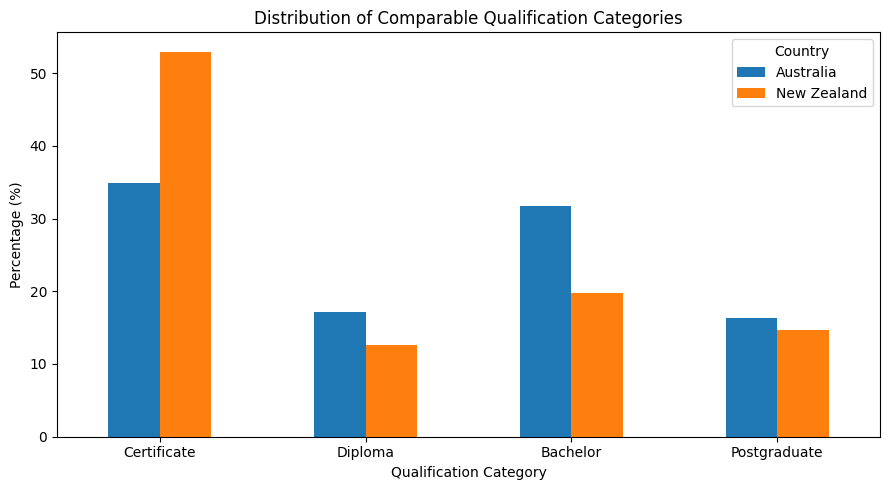

In [ ]:
import matplotlib.pyplot as plt

# Set the order of qualification categories for the visualisation.
qualification_order = [
    "Certificate",
    "Diploma",
    "Bachelor",
    "Postgraduate"
]

# Arrange the data in the chosen qualification order.
plot_data = combined_comparable.copy()
plot_data["Qualification"] = pd.Categorical(
    plot_data["Qualification"],
    categories=qualification_order,
    ordered=True
)

plot_data = plot_data.sort_values("Qualification")

# Reshape the data so each country has a series of percentages.
plot_data = plot_data.pivot(
    index="Qualification",
    columns="Country",
    values="Percentage"
)

# Create a grouped bar chart.
plot_data.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Distribution of Comparable Qualification Categories")
plt.xlabel("Qualification Category")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

#### Interpretation

The distribution shows differences in the composition of the four comparable qualification categories between Australia and New Zealand. Certificate qualifications account for the largest share in both countries, but the proportion is substantially higher in New Zealand (52.95%) than in Australia (34.84%). In contrast, Bachelor qualifications represent a larger share in Australia (31.73%) than in New Zealand (19.76%).

Diploma qualifications also account for a larger proportion in Australia (17.12%) than in New Zealand (12.55%). The proportions for postgraduate qualifications are relatively similar, at 16.31% in Australia and 14.73% in New Zealand.

Overall, within the comparable qualification categories used in this analysis, the Australian distribution has a larger relative share of Bachelor, Diploma and Postgraduate qualifications, while the New Zealand distribution has a larger relative share of Certificate qualifications.

### 4.2 Vocational and Higher Education Distribution

The qualification categories are further grouped into two broad levels for comparison. Certificate and Diploma qualifications are classified as vocational qualifications, while Bachelor and Postgraduate qualifications are classified as higher education qualifications.

This analysis examines the relative distribution of these two broad qualification groups within the comparable qualification categories for each country.

In [ ]:
# Group the four qualification categories into two broad education levels.
education_level_map = {
    "Certificate": "Vocational",
    "Diploma": "Vocational",
    "Bachelor": "Higher education",
    "Postgraduate": "Higher education"
}

# Apply the education-level grouping to the comparable data.
vocational_higher = combined_comparable.copy()

vocational_higher["Education Level"] = (
    vocational_higher["Qualification"].map(education_level_map)
)

# Combine the qualification counts within each education level.
vocational_higher = (
    vocational_higher
    .groupby(
        ["Country", "Education Level"],
        as_index=False
    )["Count"]
    .sum()
)

# Calculate the total comparable qualification count for each country.
country_totals = (
    vocational_higher
    .groupby("Country")["Count"]
    .transform("sum")
)

# Calculate the percentage distribution within each country.
vocational_higher["Percentage"] = (
    vocational_higher["Count"] / country_totals * 100
)

vocational_higher

,Country,Education Level,Count,Percentage
0,Australia,Higher education,5464622,48.044557
1,Australia,Vocational,5909449,51.955443
2,New Zealand,Higher education,1055520,34.495538
3,New Zealand,Vocational,2004354,65.504462


#### Visualisation

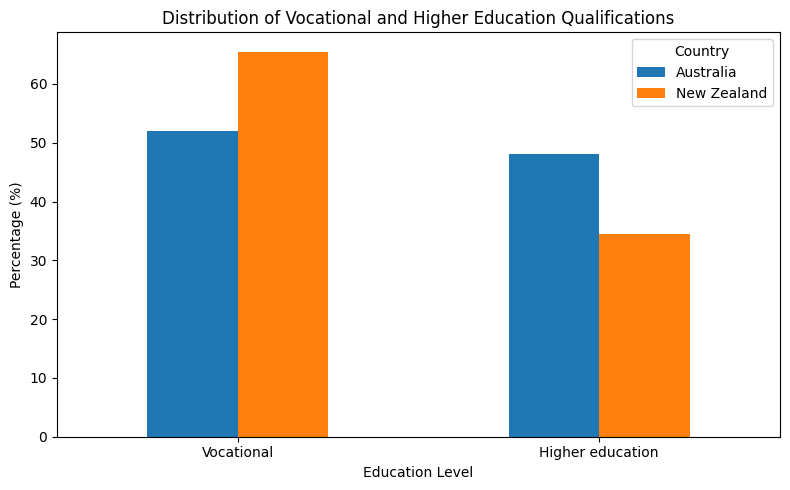

In [ ]:
# Set the order of the two broad education levels.
education_order = [
    "Vocational",
    "Higher education"
]

plot_data = vocational_higher.copy()

plot_data["Education Level"] = pd.Categorical(
    plot_data["Education Level"],
    categories=education_order,
    ordered=True
)

plot_data = plot_data.sort_values("Education Level")

# Reshape the data for the bar chart.
plot_data = plot_data.pivot(
    index="Education Level",
    columns="Country",
    values="Percentage"
)

# Create a grouped bar chart.
plot_data.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Distribution of Vocational and Higher Education Qualifications")
plt.xlabel("Education Level")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

#### Interpretation

The broad grouping shows that vocational qualifications account for a larger share of the comparable qualification categories in New Zealand (65.50%) than in Australia (51.96%). Conversely, higher education qualifications account for a larger share in Australia (48.04%) than in New Zealand (34.50%).

This indicates that, within the comparable qualification categories used in this analysis, the New Zealand distribution has a greater relative share of Certificate and Diploma qualifications, while the Australian distribution has a greater relative share of Bachelor and Postgraduate qualifications.

These results describe differences in formal qualification composition and should not be interpreted as a direct measure of the skills possessed by individuals in either population.

### 4.3 Higher Education Composition

The higher education category is examined separately by comparing the two qualification groups that make up this category: Bachelor and Postgraduate.

For this analysis, the denominator is the combined count of Bachelor and Postgraduate qualifications within each country. Therefore, the percentages describe the composition of the higher education qualifications represented in the comparable dataset, rather than the proportion of the overall population with higher education qualifications.

In [ ]:
# Select the Bachelor and Postgraduate categories.
higher_education = combined_comparable.loc[
    combined_comparable["Qualification"].isin(
        ["Bachelor", "Postgraduate"]
    )
].copy()

# Calculate the total higher education count for each country.
higher_education_totals = (
    higher_education
    .groupby("Country")["Count"]
    .transform("sum")
)

# Calculate the percentage distribution within higher education.
higher_education["Percentage"] = (
    higher_education["Count"]
    / higher_education_totals
    * 100
)

higher_education

,Country,Qualification,Count,Percentage
0,Australia,Bachelor,3609261,66.047771
3,Australia,Postgraduate,1855361,33.952229
4,New Zealand,Bachelor,604674,57.286835
7,New Zealand,Postgraduate,450846,42.713165


#### Visualisation

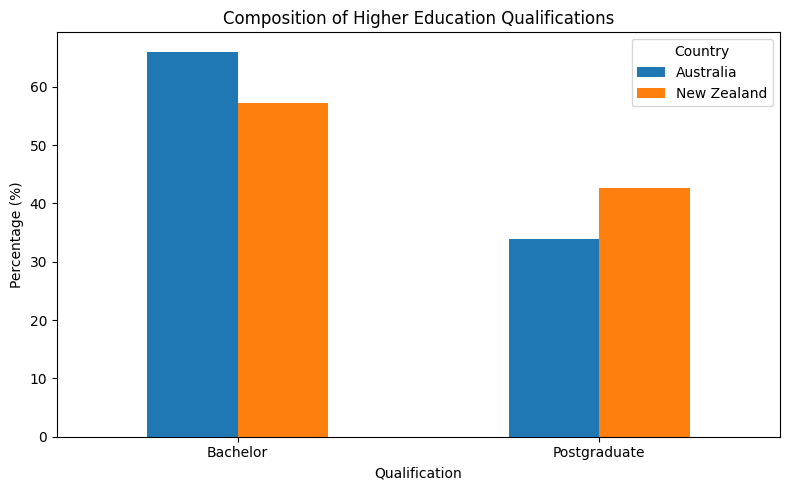

In [ ]:
# Set the order of the higher education categories.
higher_education_order = [
    "Bachelor",
    "Postgraduate"
]

plot_data = higher_education.copy()

plot_data["Qualification"] = pd.Categorical(
    plot_data["Qualification"],
    categories=higher_education_order,
    ordered=True
)

plot_data = plot_data.sort_values("Qualification")

# Reshape the data for the bar chart.
plot_data = plot_data.pivot(
    index="Qualification",
    columns="Country",
    values="Percentage"
)

# Create a grouped bar chart.
plot_data.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Composition of Higher Education Qualifications")
plt.xlabel("Qualification")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Country")
plt.tight_layout()
plt.show()

#### Interpretation

Within the higher education qualifications represented in the comparable dataset, Bachelor qualifications account for a larger share in Australia (66.05%) than in New Zealand (57.29%). Conversely, postgraduate qualifications represent a larger share in New Zealand (42.71%) than in Australia (33.95%).

This indicates that the higher education composition differs between the two countries: the Australian higher education distribution has a relatively larger Bachelor share, while the New Zealand distribution has a relatively larger postgraduate share.

These percentages describe the composition of the Bachelor and Postgraduate categories within the comparable qualification data. They do not represent the proportion of the overall population holding these qualifications.

# 5. Results and Discussion

The analysis identifies differences in the distribution of formal educational qualifications between Australia and New Zealand within the comparable qualification categories. Across the three analyses, the results show differences in the relative shares of vocational, Bachelor-level, and postgraduate qualifications.

The two countries show different distributions across the four broad qualification categories, with New Zealand having a substantially larger relative share of Certificate qualifications. Australia also has a larger relative share of Bachelor and Diploma qualifications. When the higher education categories are examined separately, Bachelor qualifications form a larger share of Australia's higher education composition, whereas postgraduate qualifications form a larger share in New Zealand.

These results describe differences in formal educational qualification composition. They should not be interpreted as evidence that one population has greater or lesser skills, because formal qualifications do not capture all skills, knowledge, experience, or competencies.

# 6. Limitations

Several limitations should be considered when interpreting the comparison.

**Different Census years:** The Australian data are from the 2021 Census, while the New Zealand data are from the 2023 Census. The results therefore represent different census years and should not be interpreted as measurements from exactly the same point in time.

**Different qualification classifications:** Australia and New Zealand use different qualification classification systems. The original categories were therefore grouped into four broader categories: Certificate, Diploma, Bachelor, and Postgraduate. This mapping simplifies some differences between the original classification systems.

**Restricted comparable denominator:** The percentages in the main comparison are calculated using only the four qualification categories that could be mapped consistently between the two countries. They therefore do not represent the percentage of the entire population aged 15 years and over.

**Additional New Zealand categories:** The New Zealand dataset contains categories such as No qualification, Overseas secondary school qualification, and Not elsewhere included. These categories were not included in the main comparison because they do not have directly corresponding categories in the selected Australian G49A data.

**Limited demographic comparability:** The Australian G49A data provide age and sex breakdowns, but the selected New Zealand extract contains total age and total ethnicity and does not provide equivalent sex-specific or age-group-specific qualification counts. Consequently, age and sex were not used for the Australia–New Zealand comparison.

**Interpretation of qualifications:** Formal educational qualifications provide information about educational attainment but are not a direct measure of an individual's skills, knowledge, experience, or competencies. The results should therefore be interpreted as differences in formal educational qualification composition rather than differences in skills.

**Assumptions used in the comparison:** The analysis assumes that the selected Australian and New Zealand qualification categories are sufficiently comparable after grouping them into the four broad categories of Certificate, Diploma, Bachelor, and Postgraduate. It also assumes that using the sum of these four comparable categories as the denominator provides a consistent basis for comparing their relative distributions between the two countries. These assumptions are necessary because the original Census classification systems and available dimensions are not identical.

# 7. Conclusion

This project compared the distribution of formal educational qualifications in Australia and New Zealand using the 2021 Australian Census and the 2023 New Zealand Census. After cleaning the datasets and mapping their different qualification classifications into four broader comparable categories, differences were observed in the relative composition of qualifications.

Within the comparable qualification categories, New Zealand had a larger relative share of Certificate qualifications, while Australia had larger relative shares of Diploma and Bachelor qualifications. The higher education analysis also showed that Bachelor qualifications formed a larger share of Australia's higher education composition, while postgraduate qualifications formed a larger share in New Zealand.

Overall, the results suggest that the formal educational qualification composition represented in the two Census datasets differs across the four comparable categories. However, these differences should be interpreted in the context of the different Census years, qualification classification systems, and restricted comparable denominator used in the analysis.

The findings describe differences in formal educational attainment and should not be interpreted as a direct comparison of the skills or capabilities of the two populations.

# 8. References

Australian Bureau of Statistics. (2021). *2021 Census: G49 – Highest non-school qualification: level of education by age by sex*. Australian Bureau of Statistics.  
https://www.abs.gov.au/census/find-census-data/datapacks?release=2021&product=GCP&geography=AU&header=S

Stats NZ. (2023). *Highest qualification, ethnicity (detailed total responses level 3), and age (life cycle groups) for the census usually resident population count aged 15 years and over, (RC, TALB, Health), 2013, 2018, and 2023 Censuses*. Stats NZ.  
https://explore.data.stats.govt.nz/vis?utm_source=chatgpt.com&tm=Highest%20qualification&pg=0&hc[Highest%20qualification]=&snb=54&df[ds]=ds-nsiws-disseminate&df[id]=CEN23_ECI_010&df[ag]=STATSNZ&df[vs]=1.0&dq=2013%2B2018%2B2023.9999%2B99999%2B999999..9999.99&to[TIME]=false